# IDC3140 Assignment 3 - Titanic Survival Prediction

This notebook explores the Titanic dataset, preprocesses the data, trains classification models, evaluates performance, compares models, and identifies important features for survival prediction.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

In [4]:
df = pd.read_csv("train.csv") #load taring set into a dataframe
df.head() #see the first few columns

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info() #identify which column exists

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.isnull().sum() #identify which columns have missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Exploration

The target variable is **Survived**, where:
- 0 = did not survive
- 1 = survived

Important features used for prediction:
- **Pclass** = passenger class
- **Sex** = male or female
- **Age** = passenger age
- **SibSp** = number of siblings/spouses aboard
- **Parch** = number of parents/children aboard
- **Fare** = ticket price
- **Embarked** = port of embarkation

In [7]:
df["Survived"].value_counts() # Count how many passengers are in each Survived category

Survived
0    549
1    342
Name: count, dtype: int64

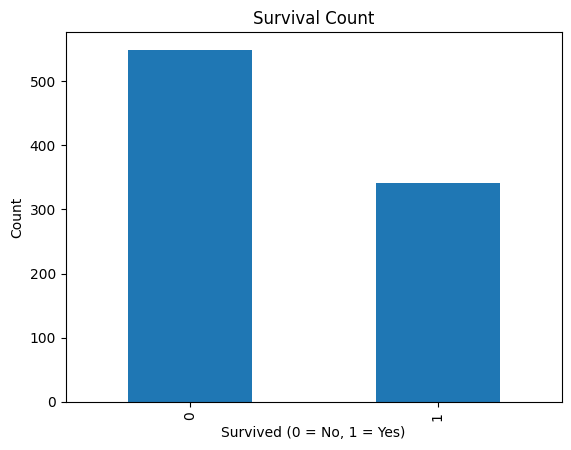

In [8]:
df["Survived"].value_counts().plot(kind="bar") # Make a bar chart showing how many people survived and how many did not
plt.title("Survival Count") # Add a title to the graph
plt.xlabel("Survived (0 = No, 1 = Yes)") #label x-axis
plt.ylabel("Count") #label y axis
plt.show() #display the graph

In [9]:
# Make a list of the column names we want to use as input features
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

# Create X by selecting only those feature columns from the dataframe
X = df[features]

# Create y as the target/output column from the dataframe
y = df["Survived"]

In [10]:
# Split the data into training and testing parts
# 80% will be used to train the model and 20% will be used to test it
# random_state=42 keeps the split the same each time you run the code
# stratify=y keeps the same balance of survival classes in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# List the number columns
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

# List the text/category columns
categorical_features = ["Sex", "Embarked"]

# Fill missing number values with the middle value
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Fill missing category values and turn words into numbers
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the right cleaning steps to number and category columns
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [12]:
# Build the KNN model pipeline with preprocessing, scaling, and classification
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean=False)),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

# Build the Decision Tree model pipeline with preprocessing and classification
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=4, random_state=42))
])

In [13]:
# Train the KNN model using the training data
knn_model.fit(X_train, y_train)

# Train the Decision Tree model using the training data
tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [14]:
# Define a function to test a model and show how well it performs
def evaluate_model(model, X_test, y_test, model_name):
    # Use the model to make predictions on the test data
    y_pred = model.predict(X_test)
    
    # Calculate the accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    
    # Calculate the precision score
    precision = precision_score(y_test, y_pred)
    
    # Calculate the recall score
    recall = recall_score(y_test, y_pred)
    
    # Create the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Print the model name
    print(f"--- {model_name} ---")
    
    # Print the accuracy result
    print("Accuracy:", round(accuracy, 4))
    
    # Print the precision result
    print("Precision:", round(precision, 4))
    
    # Print the recall result
    print("Recall:", round(recall, 4))
    
    # Print the confusion matrix
    print("Confusion Matrix:\n", cm)
    
    # Create a confusion matrix display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    # Plot the confusion matrix
    disp.plot()
    
    # Add a title to the confusion matrix graph
    plt.title(f"{model_name} Confusion Matrix")
    
    # Show the graph
    plt.show()
    
    # Return the evaluation scores
    return accuracy, precision, recall

--- k-NN ---
Accuracy: 0.8212
Precision: 0.8136
Recall: 0.6957
Confusion Matrix:
 [[99 11]
 [21 48]]


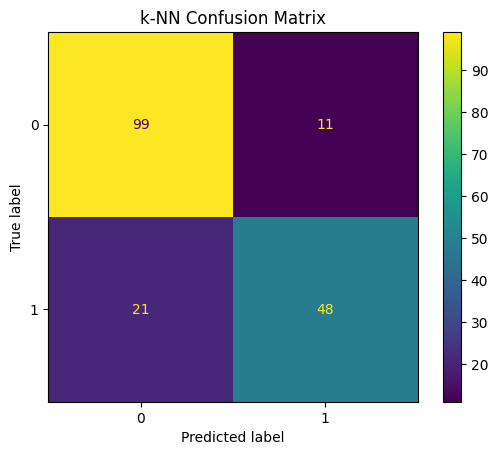

--- Decision Tree ---
Accuracy: 0.7933
Precision: 0.8636
Recall: 0.5507
Confusion Matrix:
 [[104   6]
 [ 31  38]]


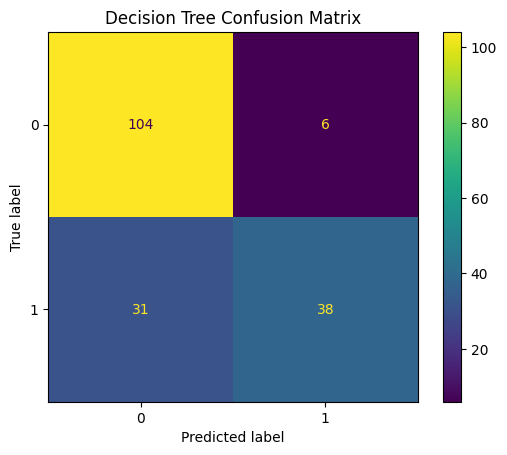

In [15]:
# Evaluate the KNN model using the test data
knn_results = evaluate_model(knn_model, X_test, y_test, "k-NN")

# Evaluate the Decision Tree model using the test data
tree_results = evaluate_model(tree_model, X_test, y_test, "Decision Tree")

In [16]:
# Create a table to compare the results of both models
results_df = pd.DataFrame({
    "Model": ["k-NN", "Decision Tree"],
    "Accuracy": [knn_results[0], tree_results[0]],
    "Precision": [knn_results[1], tree_results[1]],
    "Recall": [knn_results[2], tree_results[2]]
})

# Display the results table
results_df

,Model,Accuracy,Precision,Recall
0,k-NN,0.821229,0.813559,0.695652
1,Decision Tree,0.793296,0.863636,0.550725


In [17]:
# Run 10-fold cross-validation on the KNN model and save the accuracy scores
knn_cv_scores = cross_val_score(knn_model, X, y, cv=10, scoring="accuracy")

# Run 10-fold cross-validation on the Decision Tree model and save the accuracy scores
tree_cv_scores = cross_val_score(tree_model, X, y, cv=10, scoring="accuracy")

# Print the average cross-validation accuracy for the KNN model
print("k-NN Average CV Accuracy:", round(knn_cv_scores.mean(), 4))

# Print the average cross-validation error rate for the KNN model
print("k-NN Average CV Error Rate:", round(1 - knn_cv_scores.mean(), 4))

# Print the average cross-validation accuracy for the Decision Tree model
print("Decision Tree Average CV Accuracy:", round(tree_cv_scores.mean(), 4))

# Print the average cross-validation error rate for the Decision Tree model
print("Decision Tree Average CV Error Rate:", round(1 - tree_cv_scores.mean(), 4))

k-NN Average CV Accuracy: 0.8014
k-NN Average CV Error Rate: 0.1986
Decision Tree Average CV Accuracy: 0.8037
Decision Tree Average CV Error Rate: 0.1963


In [18]:
# Train the Decision Tree model using the training data
tree_model.fit(X_train, y_train)

# Get the names of the processed feature columns
feature_names = tree_model.named_steps["preprocessor"].get_feature_names_out()

# Get the importance score for each feature from the Decision Tree model
importances = tree_model.named_steps["classifier"].feature_importances_

# Create a table of feature names and their importance scores, then sort from highest to lowest
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Show the top 10 most important features
importance_df.head(10)

,Feature,Importance
5,cat__Sex_female,0.576297
0,num__Pclass,0.195920
1,num__Age,0.114526
4,num__Fare,0.063141
9,cat__Embarked_S,0.037198
2,num__SibSp,0.012109
3,num__Parch,0.000809
6,cat__Sex_male,0.000000
7,cat__Embarked_C,0.000000
8,cat__Embarked_Q,0.000000


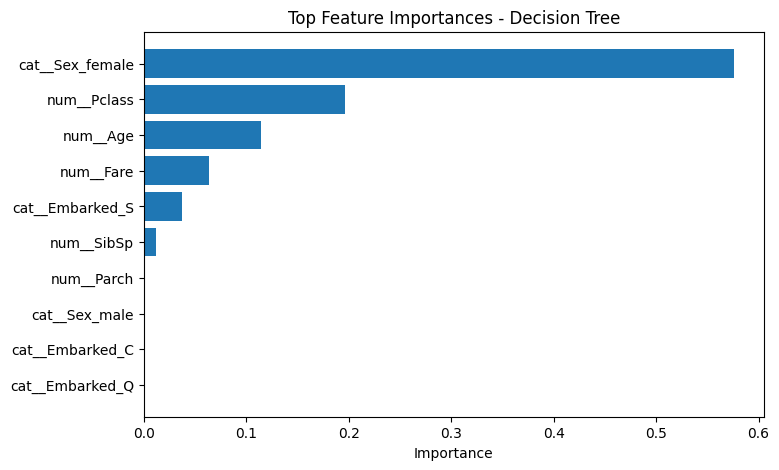

In [19]:
# Select the top 10 most important features
top_features = importance_df.head(10)

# Create a figure for the bar chart
plt.figure(figsize=(8,5))

# Make a horizontal bar chart of feature importance values
plt.barh(top_features["Feature"], top_features["Importance"])

# Flip the y-axis so the most important feature appears at the top
plt.gca().invert_yaxis()

# Add a title to the chart
plt.title("Top Feature Importances - Decision Tree")

# Label the x-axis
plt.xlabel("Importance")

# Show the chart
plt.show()

## Conclusion

Two classification models were trained on the Titanic dataset: k-NN and Decision Tree.  
Both models were evaluated using accuracy, precision, recall, confusion matrices, and 10-fold cross-validation.

The model with the better test performance and lower cross-validation error rate was considered the stronger model.  
The most important features for survival prediction were mainly related to passenger sex, class, age, and fare.

Overall, this assignment showed how preprocessing, model selection, and evaluation can be used to predict survival on the Titanic dataset.